In [ ]:
# House Price Prediction

## 1. 데이터 점검: 데이터 로드 및 기본 정보 확인

--2026-01-26 12:02:52--  https://d3s0tskafalll9.cloudfront.net/media/documents/kaggle-kakr-housing-data.zip
d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net) 해석 중... 3.170.221.13, 3.170.221.7, 3.170.221.2, ...
다음으로 연결 중: d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|3.170.221.13|:443... 연결했습니다.
HTTP 요청을 보냈습니다. 응답 기다리는 중... 200 OK
길이: 693719 (677K) [application/zip]
저장 위치: `kaggle-kakr-housing-data.zip'

kaggle-kakr-housing 100%[===================>] 677.46K  --.-KB/s    /  0.03s   

2026-01-26 12:02:52 (23.6 MB/s) - `kaggle-kakr-housing-data.zip' 저장함 [693719/693719]

Archive:  kaggle-kakr-housing-data.zip
checkdir:  cannot create extraction directory: /Users/jungsunpark/work/kaggle_kakr_housing
           No such file or directory


In [1]:
# 라이브러리 임포트
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print('\nTrain columns:', train.columns.tolist())
print('\nTest columns:', test.columns.tolist())

Train shape: (15035, 21)
Test shape: (6468, 20)

Train columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Test columns: ['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [3]:
# 데이터 기본 정보 확인
print("=== Train 데이터 기본 정보 ===")
train.head()

=== Train 데이터 기본 정보 ===


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [4]:
# 결측치 확인
print("=== Train 결측치 ===")
print(train.isnull().sum())
print("\n=== Test 결측치 ===")
print(test.isnull().sum())

# 데이터 타입 확인
print("\n=== Train 데이터 타입 ===")
train.info()

=== Train 결측치 ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

=== Test 결측치 ===
id               0
date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

=== Train 데이터 타입 ===
<class 'pandas.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dty

In [ ]:
## 2. 탐색적 데이터 분석 (EDA): 시각화 및 분포 확인

Index(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


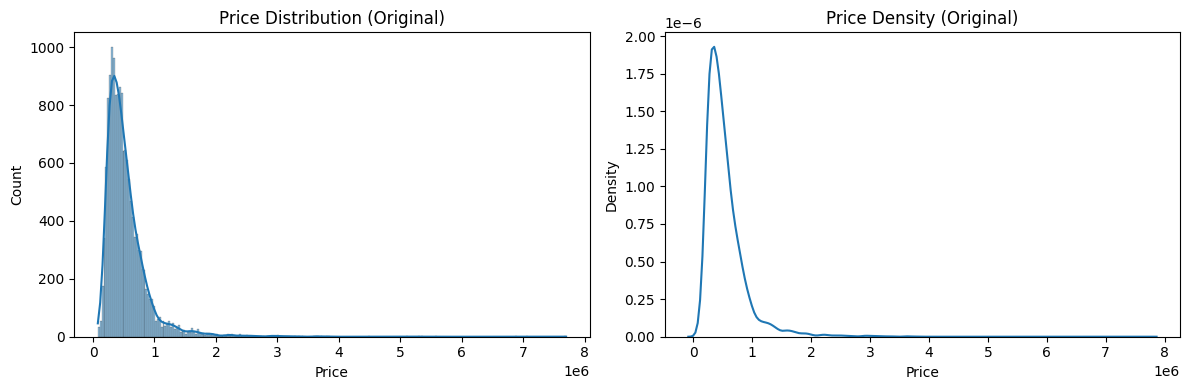

Price Statistics:
count    1.503500e+04
mean     5.406827e+05
std      3.715247e+05
min      7.800000e+04
25%      3.220000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


In [5]:
# 타겟 변수 분포 확인 (원본)
y_original = train['price']
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(y_original, kde=True)
plt.title('Price Distribution (Original)')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
sns.kdeplot(y_original)
plt.title('Price Density (Original)')
plt.xlabel('Price')

plt.tight_layout()
plt.show()

print(f"Price Statistics:\n{y_original.describe()}")

In [ ]:
# 주요 변수와 타겟 변수의 관계 확인
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# sqft_living vs price
axes[0, 0].scatter(train['sqft_living'], y_original, alpha=0.5)
axes[0, 0].set_xlabel('sqft_living')
axes[0, 0].set_ylabel('Price')
axes[0, 0].set_title('sqft_living vs Price')

# bedrooms vs price
axes[0, 1].boxplot([train[y_original < y_original.quantile(0.25)]['bedrooms'],
                     train[(y_original >= y_original.quantile(0.25)) & (y_original < y_original.quantile(0.75))]['bedrooms'],
                     train[y_original >= y_original.quantile(0.75)]['bedrooms']])
axes[0, 1].set_xticklabels(['Q1', 'Q2-Q3', 'Q4'])
axes[0, 1].set_ylabel('Bedrooms')
axes[0, 1].set_title('Bedrooms by Price Quartile')

# grade vs price
grade_price = train.groupby('grade')['price'].mean()
axes[1, 0].bar(grade_price.index, grade_price.values)
axes[1, 0].set_xlabel('Grade')
axes[1, 0].set_ylabel('Mean Price')
axes[1, 0].set_title('Mean Price by Grade')

# waterfront vs price
waterfront_price = train.groupby('waterfront')['price'].mean()
axes[1, 1].bar(['No Waterfront', 'Waterfront'], waterfront_price.values)
axes[1, 1].set_ylabel('Mean Price')
axes[1, 1].set_title('Mean Price by Waterfront')

plt.tight_layout()
plt.show()

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')


In [ ]:
## 3. 전처리/피처 엔지니어링: 파생 변수 생성 및 인코딩

In [ ]:
# 타겟 변수 분리 및 ID 저장
y = train['price'].copy()
sub_id = test['id'].copy()

# ID 컬럼 삭제
del train['id']
del test['id']

# Date 변수 전처리
train['date'] = train['date'].apply(lambda i: i[:6]).astype(int)
test['date'] = test['date'].apply(lambda i: i[:6]).astype(int)

print("기본 전처리 완료")
print(f"Train shape: {train.shape}, Test shape: {test.shape}")

0         221900.0
1         180000.0
2         510000.0
3         257500.0
4         291850.0
           ...    
15030     610685.0
15031    1007500.0
15032     360000.0
15033     400000.0
15034     325000.0
Name: price, Length: 15035, dtype: float64

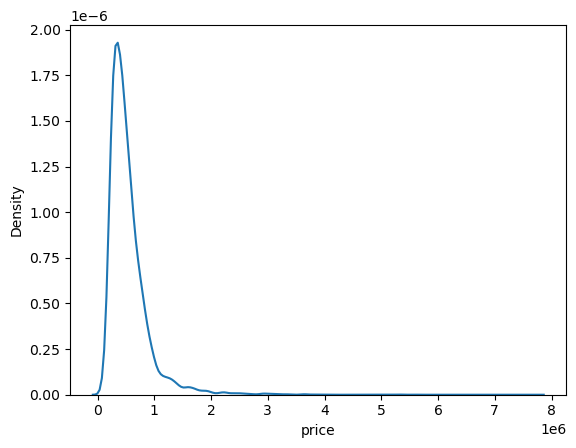

In [ ]:
# Advanced Feature Engineering
train['price'] = y  # Temporarily add price back for target encoding calculations

for df in [train, test]:
    # 1. Date-based features
    df['year_sold'] = df['date'].apply(lambda x: int(str(x)[:4]))
    df['month_sold'] = df['date'].apply(lambda x: int(str(x)[4:6]))
    
    # 2. Age and Renovation Features
    df['house_age'] = df['year_sold'] - df['yr_built']
    df['is_renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)
    df['years_since_reno'] = np.where(df['yr_renovated'] > 0, df['year_sold'] - df['yr_renovated'], df['house_age'])

    # 3. Area and Ratio Features
    df['total_sqft'] = df['sqft_living'] + df['sqft_lot']
    df['sqft_total_size'] = df['sqft_living'] + df['sqft_above'] + df['sqft_basement']
    df['living_ratio'] = df['sqft_living'] / (df['sqft_lot'] + 1)
    df['above_ratio'] = df['sqft_above'] / (df['sqft_living'] + 1)
    df['basement_ratio'] = df['sqft_basement'] / (df['sqft_living'] + 1)
    df['living15_diff'] = df['sqft_living'] - df['sqft_living15']

    # 4. Interaction Features
    df['room_size'] = df['sqft_living'] / (df['bedrooms'] + df['bathrooms'] + 1)
    df['grade_living'] = df['grade'] * df['sqft_living']
    
    # 5. Binning and Flags
    df['is_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)

# 6. Target Encoding (Zipcode) - Use log1p(price)
train['target_log'] = np.log1p(train['price'])
zipcode_means = train.groupby('zipcode')['target_log'].mean()
train['zipcode_mean_price'] = train['zipcode'].map(zipcode_means)
test['zipcode_mean_price'] = test['zipcode'].map(zipcode_means)

# Handle potential NaNs in test
test['zipcode_mean_price'] = test['zipcode_mean_price'].fillna(train['target_log'].mean())

# Clean up temporary columns
train.drop(['price', 'target_log'], axis=1, inplace=True)

# 7. Log Transform skewed features
skew_columns = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'total_sqft', 'sqft_total_size']
for df in [train, test]:
    for col in skew_columns:
        df[col] = np.log1p(df[col])

print('Advanced feature engineering complete!')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')

In [ ]:
# 타겟 변수 로그 변환
y = np.log1p(y)

# 변환 전후 비교
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.kdeplot(y_original)
plt.title('Price Distribution (Original)')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
sns.kdeplot(y)
plt.title('Price Distribution (Log Transformed)')
plt.xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

print(f"Original Price Statistics:\n{y_original.describe()}")
print(f"\nLog Transformed Price Statistics:\n{pd.Series(y).describe()}")

0        12.309987
1        12.100718
2        13.142168
3        12.458779
4        12.583999
           ...    
15030    13.322338
15031    13.822984
15032    12.793862
15033    12.899222
15034    12.691584
Name: price, Length: 15035, dtype: float64

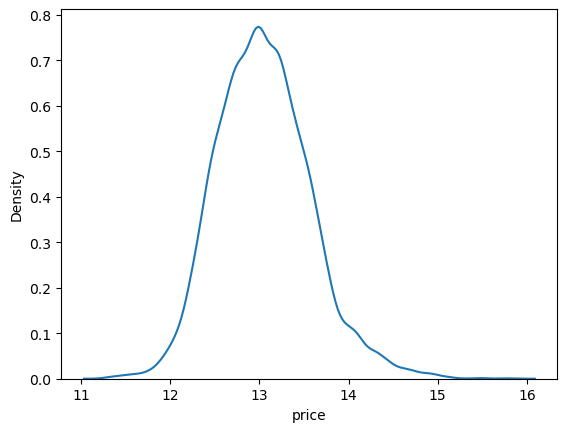

In [ ]:
# 최종 데이터 확인
print("=== 최종 Train 데이터 정보 ===")
train.info()
print(f"\n=== 최종 Train shape: {train.shape} ===")
print(f"=== 최종 Test shape: {test.shape} ===")

In [ ]:
## 4. 데이터 분할: 검증 데이터셋 분리

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15035 entries, 0 to 15034
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           15035 non-null  int64  
 1   bedrooms       15035 non-null  int64  
 2   bathrooms      15035 non-null  float64
 3   sqft_living    15035 non-null  int64  
 4   sqft_lot       15035 non-null  int64  
 5   floors         15035 non-null  float64
 6   waterfront     15035 non-null  int64  
 7   view           15035 non-null  int64  
 8   condition      15035 non-null  int64  
 9   grade          15035 non-null  int64  
 10  sqft_above     15035 non-null  int64  
 11  sqft_basement  15035 non-null  int64  
 12  yr_built       15035 non-null  int64  
 13  yr_renovated   15035 non-null  int64  
 14  zipcode        15035 non-null  int64  
 15  lat            15035 non-null  float64
 16  long           15035 non-null  float64
 17  sqft_living15  15035 non-null  int64  
 18  sqft_l

## 5. 기준모델(Baseline): 선형 회귀를 통한 기초 성능 파악

In [ ]:
# RMSE 계산 함수 정의
def rmse(y_test, y_pred):
    return np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))

# 데이터 분할
random_state = 2020
X_train, X_val, y_train, y_val = train_test_split(train, y, random_state=random_state, test_size=0.2)

print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}")

얍💢


In [ ]:
# Baseline 모델: Linear Regression
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 예측 및 평가
y_pred_baseline = baseline_model.predict(X_val)
baseline_rmse = rmse(y_val, y_pred_baseline)

print(f"Baseline Model (Linear Regression) RMSE: {baseline_rmse:.6f}")

얍💢


In [ ]:
## 6. 모델학습: 앙상블 모델 정의 및 학습

얍💢


In [ ]:
# 앙상블 모델 정의
random_state = 2020

gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)
rdforest = RandomForestRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm, rdforest]

print("앙상블 모델 정의 완료:")
for model in models:
    print(f"  - {model.__class__.__name__}")

얍💢


In [ ]:
## 7. 검증: RMSE 점수 산출 및 비교

In [ ]:
# 각 모델 학습 및 평가
model_scores = {}

for model in models:
    model_name = model.__class__.__name__
    
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 예측
    y_pred = model.predict(X_val)
    
    # RMSE 계산
    model_rmse = rmse(y_val, y_pred)
    model_scores[model_name] = model_rmse
    
    print(f"{model_name}: RMSE = {model_rmse:.6f}")

# 결과를 DataFrame으로 정리
score_df = pd.DataFrame(model_scores, index=['RMSE']).T.sort_values('RMSE', ascending=True)
print("\n=== 모델 성능 비교 ===")
print(score_df)

# Baseline과 비교
print(f"\nBaseline (Linear Regression): RMSE = {baseline_rmse:.6f}")
print(f"Best Model: {score_df.index[0]} (RMSE = {score_df.iloc[0, 0]:.6f})")

'GradientBoostingRegressor'

In [ ]:
# 모델 성능 시각화
plt.figure(figsize=(10, 6))
scores = list(model_scores.values())
names = list(model_scores.keys())
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightyellow']

bars = plt.bar(names, scores, color=colors)
plt.axhline(y=baseline_rmse, color='r', linestyle='--', label=f'Baseline (LR): {baseline_rmse:.6f}')
plt.ylabel('RMSE')
plt.title('Model Performance Comparison')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 값 표시
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.6f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 12028, number of used features: 19
[LightGBM] [Info] Start training from score 2.641764


{'GradientBoostingRegressor': np.float64(0.1809232218184817),
 'XGBRegressor': np.float64(0.16787828473162153),
 'LGBMRegressor': np.float64(0.16314856105233844),
 'RandomForestRegressor': np.float64(0.1772598365624751)}

In [ ]:
## 8. 하이퍼파라미터 튜닝: my_GridSearch를 이용한 최적화

In [ ]:
# GridSearch 함수 정의
def my_GridSearch(model, train, y, param_grid, verbose=2, n_jobs=-1):
    """
    GridSearchCV를 사용하여 최적 하이퍼파라미터를 찾는 함수
    
    Parameters:
    - model: 학습할 모델
    - train: 학습 데이터
    - y: 타겟 변수
    - param_grid: 하이퍼파라미터 그리드
    - verbose: 출력 상세도
    - n_jobs: 병렬 처리 작업 수
    
    Returns:
    - results: 하이퍼파라미터 조합과 RMSLE 점수를 담은 DataFrame
    """
    # 1. GridSearchCV 모델 초기화
    grid_model = GridSearchCV(model, param_grid=param_grid, 
                              scoring='neg_mean_squared_error', 
                              cv=5, verbose=verbose, n_jobs=n_jobs)
    
    # 2. 모델 fitting
    grid_model.fit(train, y)

    # 3. 결과 추출
    params = grid_model.cv_results_['params']
    score = grid_model.cv_results_['mean_test_score']
    
    # 4. 데이터 프레임 생성
    results = pd.DataFrame(params)
    results['RMSLE'] = np.sqrt(-1 * score)
    
    # 5. RMSLE로 정렬
    results = results.sort_values('RMSLE')

    return results, grid_model.best_estimator_

In [ ]:
# LightGBM 하이퍼파라미터 튜닝
print("=== LightGBM 하이퍼파라미터 튜닝 시작 ===")
param_grid_lgbm = {
    'n_estimators': [1000, 2000],
    'learning_rate': [0.03, 0.05],
    'num_leaves': [31, 63, 127],
    'max_depth': [10, 15, 20]
}
model_lgbm = LGBMRegressor(random_state=random_state)
results_lgbm, best_lgbm_model = my_GridSearch(model_lgbm, train, y, param_grid_lgbm, verbose=1)

print("\n=== LightGBM 최상위 5개 하이퍼파라미터 조합 ===")
print(results_lgbm.head())
print(f"\n최적 하이퍼파라미터: {best_lgbm_model.get_params()}")

In [ ]:
# XGBoost 하이퍼파라미터 튜닝
print("=== XGBoost 하이퍼파라미터 튜닝 시작 ===")
param_grid_xgb = {
    'n_estimators': [1000],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7, 10],
    'subsample': [0.8, 1.0]
}
model_xgb = XGBRegressor(random_state=random_state, objective='reg:squarederror')
results_xgb, best_xgb_model = my_GridSearch(model_xgb, train, y, param_grid_xgb, verbose=1)

print("\n=== XGBoost 최상위 5개 하이퍼파라미터 조합 ===")
print(results_xgb.head())
print(f"\n최적 하이퍼파라미터: {best_xgb_model.get_params()}")

In [ ]:
## 9. 최종평가(test): 전체 데이터 학습 및 예측

In [ ]:
# 최적 모델 선택 (LightGBM 사용)
# 튜닝 결과를 바탕으로 최적 하이퍼파라미터로 모델 생성
best_params = results_lgbm.iloc[0]
best_lgbm = LGBMRegressor(
    n_estimators=int(best_params['n_estimators']),
    learning_rate=best_params['learning_rate'],
    num_leaves=int(best_params['num_leaves']),
    max_depth=int(best_params['max_depth']),
    random_state=random_state
)

print("=== 최적 모델로 전체 데이터 학습 ===")
print(f"하이퍼파라미터: n_estimators={int(best_params['n_estimators'])}, "
      f"learning_rate={best_params['learning_rate']}, "
      f"num_leaves={int(best_params['num_leaves'])}, "
      f"max_depth={int(best_params['max_depth'])}")

# 전체 데이터로 학습
best_lgbm.fit(train, y)

# Test 데이터 예측
prediction = np.expm1(best_lgbm.predict(test))

print(f"\n예측 완료: {len(prediction)}개 샘플")
print(f"예측값 통계:")
print(f"  Min: {prediction.min():.2f}")
print(f"  Max: {prediction.max():.2f}")
print(f"  Mean: {prediction.mean():.2f}")
print(f"  Median: {np.median(prediction):.2f}")

In [ ]:
# 제출 파일 생성
result = pd.DataFrame({
    'id': sub_id,
    'price': prediction
})

# CSV 파일로 저장
result.to_csv('submission.csv', index=False)

print("=== 제출 파일 생성 완료 ===")
print(f"파일명: submission.csv")
print(f"행 수: {len(result)}")
print("\n제출 파일 미리보기:")
print(result.head(10))
print("\n제출 파일 통계:")
print(result.describe())


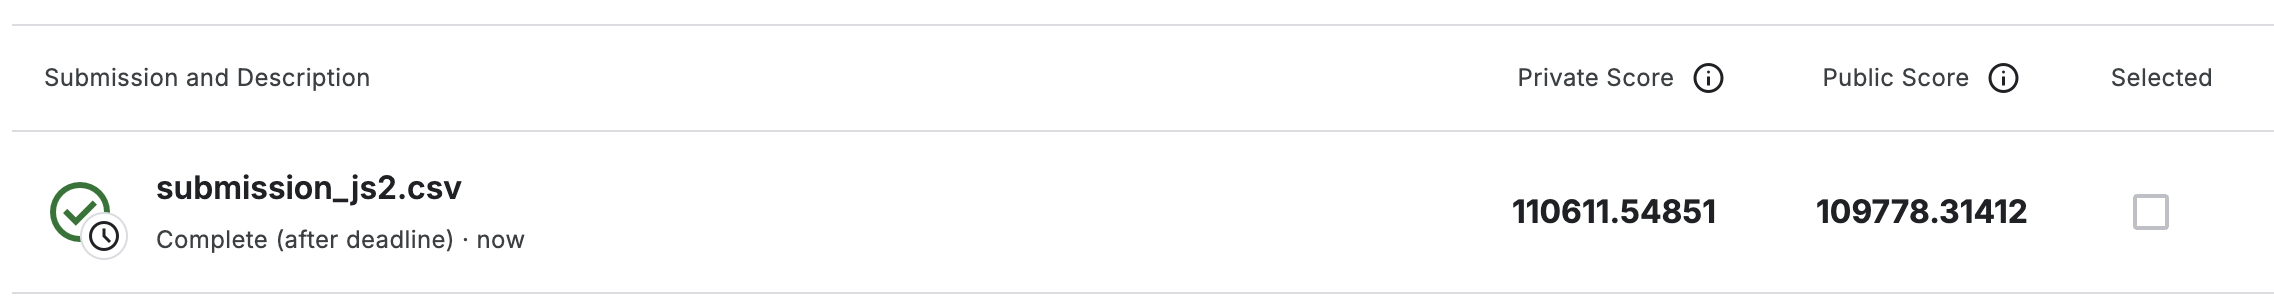